# <center>**VQE. tight binding + sd-interaction + on-site Coulomb repulsion, various cluster ansatze. 2 nodes**


In this notebook I study tigh-binding model with sd-interaction and the on-site Coulomb repuslion using VQE algorithm. I test few different ansatze as well as various initial guesses. I modify cluster ansatz by Yordanov (PHYSICAL REVIEW A 102, 062612 (2020)) to reduce number of CX gates in the circuit. Problem agnostic anzats is also used. The way to create initial guess is based not on Hartree-Fock solution but rather on strobgly correlated AFM states. The work is in progress now. The next steps would be: 1) to study interesting systems with ring geometry and non-coplanar magnetic state, 2) Studying not only ground state, but also excite states; 3) Studying cases beyond the half-filing; 4) Getting the full phase diagram of the system; 5) Using actual quantum hardware and define the biggest system size that can be tackled. 

Below are some preliminary conclusions of the study.

## Calculation speed

1. 3 nodes, 3 electrons

   Single PC, Intel core i7

   __Yordanov ansatz: 1000 iteration, 110 sec__

   Even if I start with correct solution, it takes 55 sec to finish simulations. In a first iteration it jumps of the solution and then slowly returns back. Requires 15k cx gates.

    __"Classical" cluster ansatz: 1000 iterations, 325 sec__

   3 times longer than Yordanov ansatz, which is in agreement to 3 times longer quantum circuit for classical ansatz.

   __Problem agnostic short ansatz (2 layers of rotations and entagling) with particle conservation in the cost function: 1000 iterations, 15 sec__

   This ansatz is not reliable, does not give correct solution all the time. Depends on initial parameters values.

   __Using only single exciations in the anzats: 1000 iterations, 8 sec__

   Looks like using single excitations is enough to get any wave function. This is because single excitations are performed one after another and act on superposition states. Not clear why we need double excitations. Circuit depth at that is much shorter. It requires about 750 cx gates only.


## Dependence on the system size

Comment: test is performed with U>> J,t. Initial state is one of the AFM states minimizing the Coulomb energy. There is degeracy of the Coulomb energy. There are several states with the same energy. Combination of these state allows to minimize the kinetic energy as well. This is what VQE is doing in this test.

1. 2 nodes

   Gets correct ground state withn 3 seconds. cx: 30, 600 interations to get convergence

   2 nodes + 2 electrons, no periodic boundary conditions, J = 0. Exact solution: E_gs = -sqrt(U_c^2 + 2t^2).

   For U_c = 10 and t = 1 we get E_gs = -10.198. VQE with 6000 iterations gives -10.1. So, we get 1% precision. At 30k iterations we get -10.1977, 0.003% precision

3. 3 nodes

   40 secs for 3000 iterations. cx: 84, do not get convergence. Looks like better ground state can be achieved.

   Even with 12k iterations there is no convergence. However, the final state is very close to the ground state.

4. 4 nodes

   Cx: 170, 100 sec for 3000 iteration. No conversion. Even 12k  iteratoins (450 secs) is not enough to get the correct answer. Even 36k iteration is not enough for the convergence.
   

## Classical opimizers list

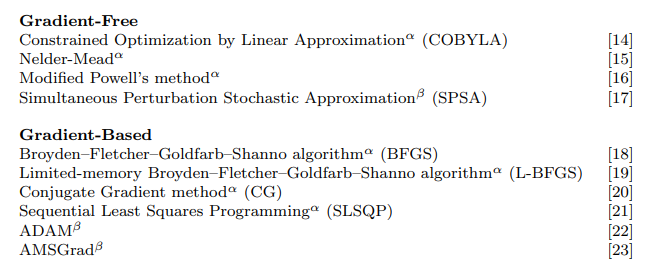

Here is the graph showing comparison of varios optimizer from Ref. "A Comparison of Various Classical Optimizers for a
Variational Quantum Linear Solver" arXiv:2106.08682v1 (2021)

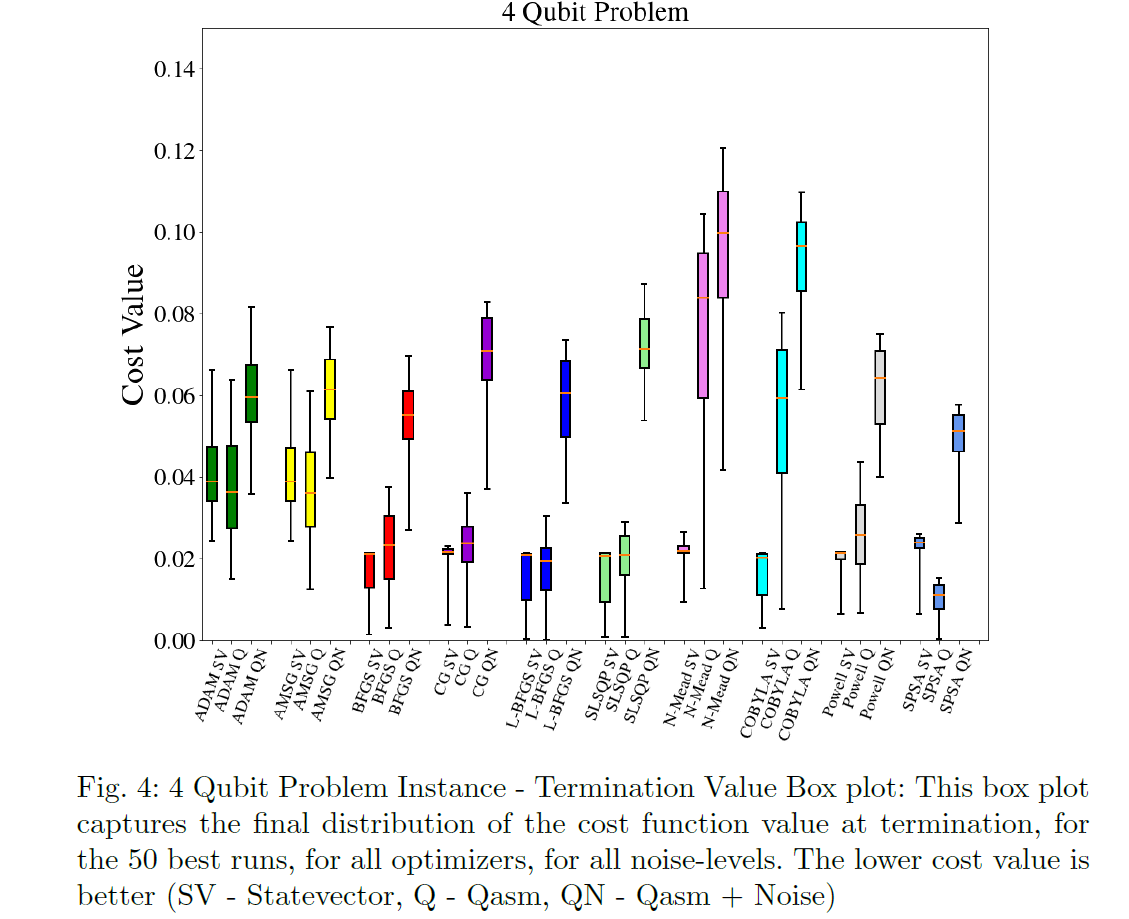

In [1]:
#Qiskit modules
import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R
from qiskit_aer import Aer
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
#from qiskit_ibm_runtime import EstimatorV2 as Estimator, QiskitRuntimeService
from qiskit_aer.primitives import EstimatorV2 as Estimator
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer.noise import NoiseModel, depolarizing_error

#math modules
import math
import numpy as np
import random

#Showing results
import matplotlib.pyplot as plt

# SciPy minimizer routine
from scipy.optimize import minimize

import time
import sys
sys.path.insert(0, 'C:/Users/Oleg/Google Диск/QC/Codes/QC-qiskit-codes/Library')
sys.path.insert(0, 'D:/GD\Мой диск/QC/Codes/QC-qiskit-codes/Library')


#My libraries
import vqe_funcs
import aux_func as af

from vqe_funcs import sigma_x, sigma_y, sigma_z, kinetic_energy, full_ham, particles_number_control

In [2]:
PI = np.pi

## States enumeration 

This is spin-depenedent version, so each node has spin-coordinate and is described by 2 qubits.

Spin-up state for node i is described by qubit i.

Spin-down state for node i is described by qubit i + N, where N is the nodes number.

## Magnetization distribution description

In [3]:
#Uniform magnetization along z axis
#In general, non-uniform magnetization can be used
def uniform_z(nodes_number):
    mag = []
    for i in range(nodes_number):
        mag.append([0, 0, 1])
    return mag

## Various ansatze

In [370]:
# Anzatz from Yordanov paper including SINGLE and DOUBLE QUBITs excitations.  Initial state is FM
def anzatz_1(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    for i in range(electrons_number):
        v_qc.x(i)
    v_qc = vqe_funcs.exc_yordanov_no_stair(qubits_number, theta, v_qc)
    return v_qc

In [371]:
# Anzatz from Yordanov paper including SINGLE and DOUBLE QUBITs excitations.  Initial state is  2 x AFM states 
def anzatz_2(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    v_qc.h(0)
    for i in range(2 * nodes_number - 1):
        v_qc.cx(i, i + 1)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    for i in range(nodes_number, 2 * nodes_number):
        if (i - nodes_number) % 2 != 0:
            v_qc.x(i)
    v_qc = vqe_funcs.exc_yordanov_no_stair(qubits_number, theta, v_qc)
    return v_qc

In [372]:
# Anzatz from Yordanov paper including SINGLE and DOUBLE QUBITs excitations.  Initial state is  a 1 x AFM state
def anzatz_3(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    for i in range(nodes_number, 2 * nodes_number):
        if (i - nodes_number) % 2 != 0:
            v_qc.x(i)
    v_qc = vqe_funcs.exc_yordanov_no_stair(qubits_number, theta, v_qc)
    return v_qc  

In [373]:
# Anzatz from Yordanov paper including only SINGLE QUBITs excitations. Initial state is FM state 
def anzatz_4(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    #initial state preparation
    for i in range(electrons_number):
        v_qc.x(i)
    #Variable block
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder(qubits_number, theta, v_qc, 0)
    return v_qc

In [374]:
# Anzatz from Yordanov paper including only SINGLE QUBITs excitations. Initial state is 2 x AFM states 
def anzatz_5(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    v_qc.h(0)
    for i in range(2 * nodes_number - 1):
        v_qc.cx(i, i + 1)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    for i in range(nodes_number, 2 * nodes_number):
        if (i - nodes_number) % 2 != 0:
            v_qc.x(i)
    
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder(qubits_number, theta, v_qc, 0)
    return v_qc

In [375]:
# Anzatz from Yordanov paper including only SINGLE QUBITs excitations. Initial state is a 1 x AFM states 
def anzatz_6(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    for i in range(nodes_number, 2 * nodes_number):
        if (i - nodes_number) % 2 != 0:
            v_qc.x(i)
    
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder(qubits_number, theta, v_qc, 0)
    return v_qc

In [376]:
# Classiccal cluster anzatz including SINGLE and DOUBLE FERMIONIC excitations.  Initial state is FM
def anzatz_7(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    #initial state preparation
    for i in range(electrons_number):
        v_qc.x(i)
    #Variable block
    v_qc = vqe_funcs.exc(qubits_number, theta, v_qc)
    return v_qc

In [377]:
# Classiccal cluster anzatz including SINGLE and DOUBLE FERMIONIC excitations.  Initial state is a 2 x AFM
def anzatz_8(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    #initial state preparation
    v_qc.h(0)
    for i in range(2 * nodes_number - 1):
        v_qc.cx(i, i + 1)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    for i in range(nodes_number, 2 * nodes_number):
        if (i - nodes_number) % 2 != 0:
            v_qc.x(i)
    #Variable block
    v_qc = vqe_funcs.exc(qubits_number, theta, v_qc)
    return v_qc

In [378]:
# Classiccal cluster anzatz including SINGLE and DOUBLE FERMIONIC excitations.  Initial state is 1 x AFM
def anzatz_9(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    #initial state preparation
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    for i in range(nodes_number, 2 * nodes_number):
        if (i - nodes_number) % 2 != 0:
            v_qc.x(i)
    #Variable block
    v_qc = vqe_funcs.exc(qubits_number, theta, v_qc)
    return v_qc

In [5]:
# Generic ansatz 2.  Initial state is FM
def anzatz_10(theta, nodes_number, el_num):
    #theta should have 4 * 3 * 2 * nodes_number elements 
    
    #initial guess creatin
    q_r = Q_R(nodes_number * 2)
    v_qc = QuantumCircuit(q_r)
    
    #Initial guess preparation
    #v_qc.h(0)
    #for i in range(2 * nodes_number - 1):
    #    v_qc.cx(i, i + 1)
    #for i in range(nodes_number):
    #    if i % 2 == 0:
    #        v_qc.x(i)
    #for i in range(nodes_number, 2 * nodes_number):
    #    if (i - nodes_number) % 2 != 0:
    #        v_qc.x(i)

    #for i in range(el_num):
    #    v_qc.x(i)
    #variational block        
    i_theta = 0
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1

    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1

    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        
    return v_qc

In [380]:
# Generic ansatz 2.  Initial state is 2 x AFM
def anzatz_11(theta, nodes_number, el_num):
    #theta should have 4 * 3 * 2 * nodes_number elements 
    
    #initial guess creatin
    q_r = Q_R(nodes_number * 2)
    v_qc = QuantumCircuit(q_r)
    
    #Initial guess preparation
    v_qc.h(0)
    for i in range(2 * nodes_number - 1):
        v_qc.cx(i, i + 1)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    for i in range(nodes_number, 2 * nodes_number):
        if (i - nodes_number) % 2 != 0:
            v_qc.x(i)

    #for i in range(el_num):
    #    v_qc.x(i)
    #variational block        
    i_theta = 0
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1

    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1

    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
    
    return v_qc

In [381]:
# Generic ansatz 2.  Initial state is 1 x AFM
def anzatz_12(theta, nodes_number, el_num):
    #theta should have 4 * 3 * 2 * nodes_number elements 
    
    #initial guess creatin
    q_r = Q_R(nodes_number * 2)
    v_qc = QuantumCircuit(q_r)
    
    #Initial guess preparation
    #v_qc.h(0)
    #for i in range(2 * nodes_number - 1):
    #    v_qc.cx(i, i + 1)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    #for i in range(nodes_number, 2 * nodes_number):
    #    if (i - nodes_number) % 2 != 0:
    #        v_qc.x(i)

    #for i in range(el_num):
    #    v_qc.x(i)
    #variational block        
    #variational block        
    i_theta = 0
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1

    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1

    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
    
    return v_qc

In [382]:
# Generic ansatz.  Initial state is FM
def anzatz_10_1(theta, nodes_number, el_num):
    #theta should have 4 * 3 * 2 * nodes_number elements 
    
    #initial guess creatin
    q_r = Q_R(nodes_number * 2)
    v_qc = QuantumCircuit(q_r)
    
    #Initial guess preparation
    #v_qc.h(0)
    #for i in range(2 * nodes_number - 1):
    #    v_qc.cx(i, i + 1)
    #for i in range(nodes_number):
    #    if i % 2 == 0:
    #        v_qc.x(i)
    #for i in range(nodes_number, 2 * nodes_number):
    #    if (i - nodes_number) % 2 != 0:
    #        v_qc.x(i)

    for i in range(el_num):
        v_qc.x(i)
    #variational block        
    i_theta = 0
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1

    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
    
    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i + nodes_number, i)
    for i in range(0, nodes_number - 1):
        v_qc.h(i)
        v_qc.cx(i + 1, i)
    for i in range(nodes_number, 2 * nodes_number - 1):
        v_qc.h(i)
        v_qc.cx(i + 1, i)

    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1

    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
    
    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i + nodes_number, i)
    for i in range(0, nodes_number - 1):
        v_qc.h(i)
        v_qc.cx(i + 1, i)
    for i in range(nodes_number, 2 * nodes_number - 1):
        v_qc.h(i)
        v_qc.cx(i + 1, i)
        
    return v_qc

In [383]:
# Generic ansatz.  Initial state is FM
def anzatz_11_1(theta, nodes_number, el_num):
    #theta should have 4 * 3 * 2 * nodes_number elements 
    
    #initial guess creatin
    q_r = Q_R(nodes_number * 2)
    v_qc = QuantumCircuit(q_r)
    
    #Initial guess preparation
    v_qc.h(0)
    for i in range(2 * nodes_number - 1):
        v_qc.cx(i, i + 1)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    for i in range(nodes_number, 2 * nodes_number):
        if (i - nodes_number) % 2 != 0:
            v_qc.x(i)

    #for i in range(el_num):
    #    v_qc.x(i)
    #variational block        
    i_theta = 0
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1

    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
    
    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i + nodes_number, i)
    for i in range(0, nodes_number - 1):
        v_qc.h(i)
        v_qc.cx(i + 1, i)
    for i in range(nodes_number, 2 * nodes_number - 1):
        v_qc.h(i)
        v_qc.cx(i + 1, i)

    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1

    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
    
    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i + nodes_number, i)
    for i in range(0, nodes_number - 1):
        v_qc.h(i)
        v_qc.cx(i + 1, i)
    for i in range(nodes_number, 2 * nodes_number - 1):
        v_qc.h(i)
        v_qc.cx(i + 1, i)
        
    return v_qc

In [384]:
# Generic ansatz.  Initial state is FM
def anzatz_12_1(theta, nodes_number, el_num):
    #theta should have 4 * 3 * 2 * nodes_number elements 
    
    #initial guess creatin
    q_r = Q_R(nodes_number * 2)
    v_qc = QuantumCircuit(q_r)
    
    #Initial guess preparation
    #v_qc.h(0)
    #for i in range(2 * nodes_number - 1):
    #    v_qc.cx(i, i + 1)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    #for i in range(nodes_number, 2 * nodes_number):
    #    if (i - nodes_number) % 2 != 0:
    #        v_qc.x(i)

    #for i in range(el_num):
    #    v_qc.x(i)
    #variational block        
    i_theta = 0
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1

    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
    
    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i + nodes_number, i)
    for i in range(0, nodes_number - 1):
        v_qc.h(i)
        v_qc.cx(i + 1, i)
    for i in range(nodes_number, 2 * nodes_number - 1):
        v_qc.h(i)
        v_qc.cx(i + 1, i)

    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1

    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i, i + nodes_number)
    for i in range(0, nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
    for i in range(nodes_number, 2 * nodes_number-1):
        v_qc.h(i)
        v_qc.cx(i, i + 1)
        
    for i in range(0, nodes_number * 2):
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.ry(theta[i_theta],i)
        i_theta = i_theta + 1
        v_qc.rx(theta[i_theta],i)
        i_theta = i_theta + 1
    
    for i in range(0, nodes_number):
        v_qc.h(i)
        v_qc.cx(i + nodes_number, i)
    for i in range(0, nodes_number - 1):
        v_qc.h(i)
        v_qc.cx(i + 1, i)
    for i in range(nodes_number, 2 * nodes_number - 1):
        v_qc.h(i)
        v_qc.cx(i + 1, i)
        
    return v_qc

In [385]:
# Anzatz from Yordanov paper including only SINGLE QUBITs excitations. Initial state is FM state, tunable length 
def anzatz_13(theta, nodes_number, electrons_number, n_tr):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    #initial state preparation
    for i in range(electrons_number):
        v_qc.x(i)
    #Variable block
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder_red(qubits_number, theta, v_qc, n_tr)
    return v_qc

In [386]:
# Anzatz from Yordanov paper including only SINGLE QUBITs excitations. Initial state is 2 x AFM states, tunable length 
def anzatz_14(theta, nodes_number, electrons_number, n_tr):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    v_qc.h(0)
    for i in range(2 * nodes_number - 1):
        v_qc.cx(i, i + 1)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    for i in range(nodes_number, 2 * nodes_number):
        if (i - nodes_number) % 2 != 0:
            v_qc.x(i)
    
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder_red(qubits_number, theta, v_qc, n_tr)
    return v_qc

In [387]:
# Anzatz from Yordanov paper including only SINGLE QUBITs excitations. Initial state is a 1 x AFM states, tunable length
def anzatz_15(theta, nodes_number, electrons_number, n_tr):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    for i in range(nodes_number, 2 * nodes_number):
        if (i - nodes_number) % 2 != 0:
            v_qc.x(i)
    
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder_red(qubits_number, theta, v_qc, n_tr)
    return v_qc

In [388]:
# Anzatz from Yordanov paper including only SINGLE QUBITs excitations, but 3 times. Initial state is FM state
def anzatz_16(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    #initial state preparation
    for i in range(electrons_number):
        v_qc.x(i)
    #Variable block
    len_tot = len(theta)
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder(qubits_number, theta[0:int(len_tot/3)], v_qc, 0)
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder(qubits_number, theta[int(len_tot/3):int(2*len_tot/3)], v_qc, 0)
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder(qubits_number, theta[int(2*len_tot/3):int(len_tot)], v_qc, 0)
    return v_qc

In [389]:
# Anzatz from Yordanov paper including only SINGLE QUBITs excitations, but 3 times. Initial state is 2 x AFM states
def anzatz_17(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    v_qc.h(0)
    for i in range(2 * nodes_number - 1):
        v_qc.cx(i, i + 1)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    for i in range(nodes_number, 2 * nodes_number):
        if (i - nodes_number) % 2 != 0:
            v_qc.x(i)
    
    len_tot = len(theta)
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder(qubits_number, theta[0:int(len_tot/3)], v_qc, 0)
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder(qubits_number, theta[int(len_tot/3):int(2*len_tot/3)], v_qc, 0)
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder(qubits_number, theta[int(2*len_tot/3):int(len_tot)], v_qc, 0)
    return v_qc

In [390]:
# Anzatz from Yordanov paper including only SINGLE QUBITs excitations, but 3 times. Initial state is a 1 x AFM states
def anzatz_18(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    for i in range(nodes_number, 2 * nodes_number):
        if (i - nodes_number) % 2 != 0:
            v_qc.x(i)
    len_tot = len(theta)
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder(qubits_number, theta[0:int(len_tot/3)], v_qc, 0)
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder(qubits_number, theta[int(len_tot/3):int(2*len_tot/3)], v_qc, 0)
    v_qc = vqe_funcs.exc_yordanov_single_only_no_ladder(qubits_number, theta[int(2*len_tot/3):int(len_tot)], v_qc, 0)
    return v_qc

In [391]:
# Anzatz from Yordanov paper including S+D  FERMION excitations. Initial state is FM state
def anzatz_19(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    #initial state preparation
    for i in range(electrons_number):
        v_qc.x(i)
    #Variable block
    v_qc = vqe_funcs.exc_yordanov(qubits_number, theta, v_qc)
    return v_qc

In [392]:
# Anzatz from Yordanov paper including only S+D FERMION excitations. Initial state is 2 x AFM states
def anzatz_20(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    v_qc.h(0)
    for i in range(2 * nodes_number - 1):
        v_qc.cx(i, i + 1)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    for i in range(nodes_number, 2 * nodes_number):
        if (i - nodes_number) % 2 != 0:
            v_qc.x(i)
    
    v_qc = vqe_funcs.exc_yordanov(qubits_number, theta, v_qc)
    return v_qc

In [393]:
# Anzatz from Yordanov paper including S+D FERMION excitations. Initial state is a 1 x AFM states
def anzatz_21(theta, nodes_number, electrons_number):
    qubits_number = 2 * nodes_number
    q_r = Q_R(qubits_number)
    v_qc = QuantumCircuit(q_r)
    for i in range(nodes_number):
        if i % 2 == 0:
            v_qc.x(i)
    for i in range(nodes_number, 2 * nodes_number):
        if (i - nodes_number) % 2 != 0:
            v_qc.x(i)
    v_qc = vqe_funcs.exc_yordanov(qubits_number, theta, v_qc)
    return v_qc

In [6]:
# Check number of gates and draw the ansatz circuit
nodes_number = 2
electrons_number = 2
n_qubits = nodes_number * 2
len_se = n_qubits * (n_qubits - 1) / 2
len_de = n_qubits * (n_qubits - 1) * (n_qubits - 2) * (n_qubits - 3) / 4 / 2
len_tot = int(len_se + len_de)
len_tot = (3 * 2 * nodes_number * 2)
theta = []
for i in range(len_tot * 3):
    theta.append(0)


init_guess = [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]

qc = anzatz_10(theta, nodes_number, electrons_number)

In [7]:
len_tot

24

In [8]:
qc.decompose().count_ops()

OrderedDict([('r', 48), ('u2', 12), ('cx', 12)])

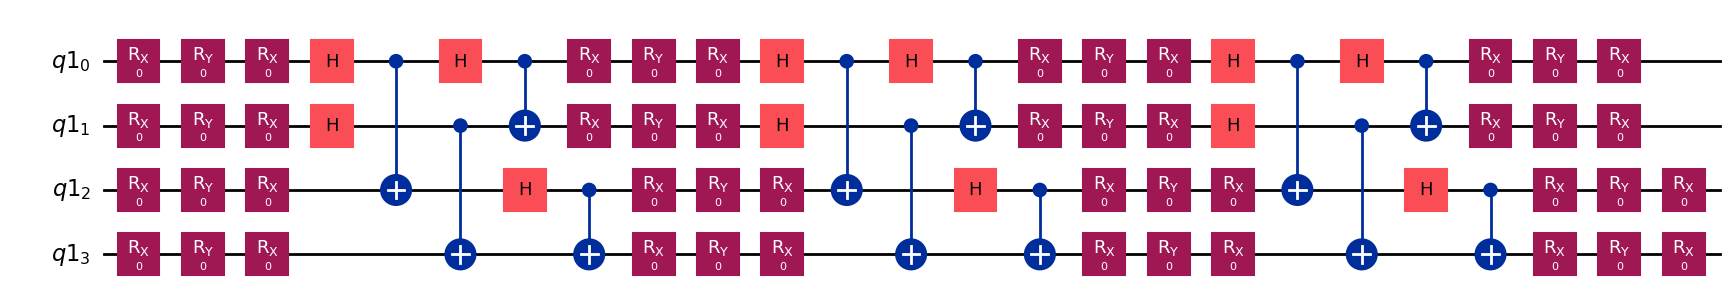

In [9]:
qc.draw('mpl')

In [10]:
from qiskit.visualization import circuit_drawer
# Draw the circuit using the matplotlib backend
fig = circuit_drawer(qc, output='mpl', style={'fontsize': 16}, fold=51)

# Add a text annotation to the figure
#fig.text(0.5, 0.90, "(a)", ha='center', fontsize=14)

# Save or show
fig.savefig("Gener.eps", format='eps', dpi=300, bbox_inches='tight')
plt.show()

## Cost functions for optimization

Cost functions use either noiseless or noisy classical simulations. There is also a cost function using real QC for calculations. 

Some of the cost functions can use varoius type of ansatze.

In [33]:
# defining a cost function. Classical simulations of the QC operations. It does not use real QC
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
def estim(theta, nodes_number, hamiltonian, electrons_number, n_red, init_guess):
    v_qc = anzatz_qc(theta, nodes_number, electrons_number, n_red, init_guess)
    
    estimator = StatevectorEstimator()

    job = estimator.run([(v_qc, hamiltonian)])
    estimator_expvals = job.result()[0].data.evs
    
      
    #print 
    #print('iter: ' + str( cost_history_dict["iters"]) + ', Energy: ' + str(estimator_expvals))
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = theta
    cost_history_dict["cost_history"].append(estimator_expvals)
    return estimator_expvals

In [34]:
# defining a cost function. Classical simulations of the QC operations. Ansatz type as a parameter
def estim_multi(theta, ansatz_type, init_state, nodes_number, hamiltonian, electrons_number, n_tr):
    
    if ansatz_type == 'Yord_double_qubits' and init_state == 'Single_FM':
        v_qc = anzatz_1(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_double_qubits' and init_state == 'Double_AFM':
        v_qc = anzatz_2(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_double_qubits' and init_state == 'Single_AFM':
        v_qc = anzatz_3(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits' and init_state == 'Single_FM':
        v_qc = anzatz_4(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits' and init_state == 'Double_AFM':
        v_qc = anzatz_5(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits' and init_state == 'Single_AFM':
        v_qc = anzatz_6(theta, nodes_number, electrons_number)

    if ansatz_type == 'Classic_cluster' and init_state == 'Single_FM':
        v_qc = anzatz_7(theta, nodes_number, electrons_number)

    if ansatz_type == 'Classic_cluster' and init_state == 'Double_AFM':
        v_qc = anzatz_8(theta, nodes_number, electrons_number)

    if ansatz_type == 'Classic_cluster' and init_state == 'Single_AFM':
        v_qc = anzatz_9(theta, nodes_number, electrons_number)

    if ansatz_type == 'Generic' and init_state == 'Single_FM':
        v_qc = anzatz_10(theta, nodes_number, electrons_number)

    if ansatz_type == 'Generic' and init_state == 'Double_AFM':
        v_qc = anzatz_11(theta, nodes_number, electrons_number)

    if ansatz_type == 'Generic' and init_state == 'Single_AFM':
        v_qc = anzatz_12(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_red_qubits' and init_state == 'Single_FM':
        v_qc = anzatz_13(theta, nodes_number, electrons_number, n_tr)

    if ansatz_type == 'Yord_single_red_qubits' and init_state == 'Double_AFM':
        v_qc = anzatz_14(theta, nodes_number, electrons_number, n_tr)

    if ansatz_type == 'Yord_single_red_qubits' and init_state == 'Single_AFM':
        v_qc = anzatz_15(theta, nodes_number, electrons_number, n_tr)
    
    if ansatz_type == 'Yord_single_qubits_triple' and init_state == 'Single_FM':
        v_qc = anzatz_16(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits_triple' and init_state == 'Double_AFM':
        v_qc = anzatz_17(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits_triple' and init_state == 'Single_AFM':
        v_qc = anzatz_18(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_SD_fermions' and init_state == 'Single_FM':
        v_qc = anzatz_19(theta, nodes_number, electrons_number)
    
    if ansatz_type == 'Yord_SD_fermions' and init_state == 'Double_AFM':
        v_qc = anzatz_20(theta, nodes_number, electrons_number)
    
    if ansatz_type == 'Yord_SD_fermions' and init_state == 'Single_AFM':
        v_qc = anzatz_21(theta, nodes_number, electrons_number)
    
    estimator = StatevectorEstimator()

    job = estimator.run([(v_qc, hamiltonian)])
    estimator_expvals = job.result()[0].data.evs
    
      
    #print 
    #print('iter: ' + str( cost_history_dict["iters"]) + ', Energy: ' + str(estimator_expvals))
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = theta
    cost_history_dict["cost_history"].append(estimator_expvals)
    return estimator_expvals

In [165]:
# defining a cost function. Classical simulations of the QC operations + NOISE. It does not use real QC. Ansatz type as a parameter
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
def estim_noise_multi(theta, ansatz_type, init_state, nodes_number, hamiltonian, electrons_number, n_tr):
    #Creting a noise model
    noise_model = NoiseModel()
    cx_depolarizing_prob = 0.01
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(cx_depolarizing_prob, 2), ["cx"]
    )

    if ansatz_type == 'Yord_double_qubits' and init_state == 'Single_FM':
        v_qc = anzatz_1(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_double_qubits' and init_state == 'Double_AFM':
        v_qc = anzatz_2(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_double_qubits' and init_state == 'Single_AFM':
        v_qc = anzatz_3(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits' and init_state == 'Single_FM':
        v_qc = anzatz_4(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits' and init_state == 'Double_AFM':
        v_qc = anzatz_5(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits' and init_state == 'Single_AFM':
        v_qc = anzatz_6(theta, nodes_number, electrons_number)

    if ansatz_type == 'Classic_cluster' and init_state == 'Single_FM':
        v_qc = anzatz_7(theta, nodes_number, electrons_number)

    if ansatz_type == 'Classic_cluster' and init_state == 'Double_AFM':
        v_qc = anzatz_8(theta, nodes_number, electrons_number)

    if ansatz_type == 'Classic_cluster' and init_state == 'Single_AFM':
        v_qc = anzatz_9(theta, nodes_number, electrons_number)

    if ansatz_type == 'Generic' and init_state == 'Single_FM':
        v_qc = anzatz_10(theta, nodes_number, electrons_number)

    if ansatz_type == 'Generic' and init_state == 'Double_AFM':
        v_qc = anzatz_11(theta, nodes_number, electrons_number)

    if ansatz_type == 'Generic' and init_state == 'Single_AFM':
        v_qc = anzatz_12(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_red_qubits' and init_state == 'Single_FM':
        v_qc = anzatz_13(theta, nodes_number, electrons_number, n_tr)

    if ansatz_type == 'Yord_single_red_qubits' and init_state == 'Double_AFM':
        v_qc = anzatz_14(theta, nodes_number, electrons_number, n_tr)

    if ansatz_type == 'Yord_single_red_qubits' and init_state == 'Single_AFM':
        v_qc = anzatz_15(theta, nodes_number, electrons_number, n_tr)
    
    if ansatz_type == 'Yord_single_qubits_triple' and init_state == 'Single_FM':
        v_qc = anzatz_16(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits_triple' and init_state == 'Double_AFM':
        v_qc = anzatz_17(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits_triple' and init_state == 'Single_AFM':
        v_qc = anzatz_18(theta, nodes_number, electrons_number)

    if ansatz_type == 'Yord_SD_fermions' and init_state == 'Single_FM':
        v_qc = anzatz_19(theta, nodes_number, electrons_number)
    
    if ansatz_type == 'Yord_SD_fermions' and init_state == 'Double_AFM':
        v_qc = anzatz_20(theta, nodes_number, electrons_number)
    
    if ansatz_type == 'Yord_SD_fermions' and init_state == 'Single_AFM':
        v_qc = anzatz_21(theta, nodes_number, electrons_number)
    
    
    pass_manager = generate_preset_pass_manager(3, AerSimulator())
    v_qc_isa = pass_manager.run(v_qc)
    noisy_estimator = Estimator(
        options=dict(backend_options=dict(noise_model=noise_model))
    )

    #Run the estimator 
    pub = (v_qc_isa, hamiltonian)
    job = noisy_estimator.run([pub])
    estimator_expvals = job.result()[0].data.evs
    
      
    #print 
    #print('iter: ' + str( cost_history_dict["iters"]) + ', Energy: ' + str(estimator_expvals))
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = theta
    cost_history_dict["cost_history"].append(estimator_expvals)
    return estimator_expvals

In [36]:
# defining a cost function. Classical simulations of the QC operations + NOISE. It does not use real QC
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
def estim_noise(theta, nodes_number, hamiltonian, electrons_number, n_red, init_guess):
    #Creting a noise model
    noise_model = NoiseModel()
    cx_depolarizing_prob = 0.01
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(cx_depolarizing_prob, 2), ["cx"]
    )

    #Creating a quantum circuit
    v_qc = anzatz_qc(theta, nodes_number, electrons_number, n_red, init_guess)
    
    pass_manager = generate_preset_pass_manager(3, AerSimulator())
    v_qc_isa = pass_manager.run(v_qc)
    noisy_estimator = Estimator(
        options=dict(backend_options=dict(noise_model=noise_model))
    )

    #Run the estimator 
    pub = (v_qc_isa, hamiltonian)
    job = noisy_estimator.run([pub])
    estimator_expvals = job.result()[0].data.evs
    
      
    #print 
    #print('iter: ' + str( cost_history_dict["iters"]) + ', Energy: ' + str(estimator_expvals))
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = theta
    cost_history_dict["cost_history"].append(estimator_expvals)
    return estimator_expvals

In [37]:
# defining a cost function. Energy estimation using real IBM QC
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
def estim_qc(theta, nodes_number, hamiltonian, electrons_number, n_red, init_guess, backend):
    v_qc = anzatz_qc(theta, nodes_number, electrons_number, n_red, init_guess)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=2)
    isa_circuit = pm.run(v_qc)
    #estimator = StatevectorEstimator()
    isa_circuit.draw('mpl')
    estimator = Estimator(backend)
    observable_isa = hamiltonian.apply_layout(layout=isa_circuit.layout)
    #print(observable_isa)
    job = estimator.run([(isa_circuit, observable_isa)])
    estimator_expvals = job.result()[0].data.evs
    #print 
    #print('iter: ' + str( cost_history_dict["iters"]) + ', Energy: ' + str(estimator_expvals))
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = theta
    cost_history_dict["cost_history"].append(estimator_expvals)
    return estimator_expvals

In [38]:
#testing estimator using the initial guess of the ansatz using classical simulations of QC
nodes_number = 3
electrons_number = 3
n_qubits = nodes_number * 2
len_se = n_qubits * (n_qubits - 1) / 2
len_de = n_qubits * (n_qubits - 1) * (n_qubits - 2) * (n_qubits - 3) / 4 / 2
len_tot = int(len_se + len_de)

theta = [0]
for i in range(len_tot):
    theta.append(0)


init_guess = [1, 0, 0, 1]
J = 0.10 #s-d exchange constant
t = 1 #hopping matrix element (kinetic energy coefficient)
electrons_number = 3
n_red = 0
U_c = 10

hamiltonian = full_ham(nodes_number, uniform_z(nodes_number), J, t, U_c, periodic = False)
#print(hamiltonian)
estim(theta, nodes_number, hamiltonian, electrons_number, 0, init_guess)

NameError: name 'anzatz_qc' is not defined

In [ ]:
#testing NOISY estimator using the initial guess of the ansatz using classical simulations of QC
nodes_number = 3
electrons_number = 3
n_qubits = nodes_number * 2
len_se = n_qubits * (n_qubits - 1) / 2
len_de = n_qubits * (n_qubits - 1) * (n_qubits - 2) * (n_qubits - 3) / 4 / 2
len_tot = int(len_se + len_de)

theta = [0]
for i in range(len_tot):
    theta.append(0)


init_guess = [1, 0, 0, 1]
J = 0.10 #s-d exchange constant
t = 1 #hopping matrix element (kinetic energy coefficient)
electrons_number = 3
n_red = 0
U_c = 10

hamiltonian = full_ham(nodes_number, uniform_z(nodes_number), J, t, U_c, periodic = False)
#print(hamiltonian)
estim_noise(theta, nodes_number, hamiltonian, electrons_number, 0, init_guess)

In [39]:
#testing estimator using the initial guess of the ansatz using real IBM QC

# Define the service.  This allows you to access IBM QPUs.
service = QiskitRuntimeService()
# Get a backend
backend = service.least_busy(operational=True, simulator=False)
#print(backend)

nodes_number = 3
electrons_number = 3
n_qubits = nodes_number * 2
len_se = n_qubits * (n_qubits - 1) / 2
len_de = n_qubits * (n_qubits - 1) * (n_qubits - 2) * (n_qubits - 3) / 4 / 2
len_tot = int(len_se + len_de)

theta = [0]
for i in range(len_tot):
    theta.append(0)


init_guess = [1, 0, 0, 1]
J = 0.10 #s-d exchange constant
t = 1 #hopping matrix element (kinetic energy coefficient)
n_red = 0
U_c = 10

hamiltonian = full_ham(nodes_number, uniform_z(nodes_number), J, t, U_c, periodic = False)

#v_qc = anzatz_qc(theta, nodes_number, electrons_number, n_red, init_guess)
#pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
#isa_circuit = pm.run(v_qc)
#estimator = StatevectorEstimator()
#isa_circuit.draw('mpl')

res = estim_qc(theta, nodes_number, hamiltonian, electrons_number, 0, init_guess, backend)

NameError: name 'QiskitRuntimeService' is not defined

## VQE Optimization block using classical simulations (no QC)

The test of the VQE is performed using 9 test cases shown below in the task set dscription. 

There you can chose also the ansatz type and the classical optimizer.

Depending on the choice of the cost function in the optimization function one can switch between noiseless and noisy simulations. 

In [358]:
#set of tasks
tasks = []

#List of ansatze types
#Classic_cluster
#Generic
#Yord_SD_fermions
#Yord_double_qubits
#Yord_single_qubits
#Yord_single_qubits_triple

#List of initial states
#Single_FM
#Double_AFM
#Single_AFM

#List of optimizers
#cobyla
#Powell
#BFGS
#SLSQP

#task 1
nodes_number = 2 #number of nodes
electrons_number = 2
J = 0.2 #s-d exchange constant
t = 1 #hopping matrix element (kinetic energy coefficient)
U_c = 10
opt_method = 'SLSQP'
ansatz_type = 'Yord_single_qubits_triple'
initial_state = 'Single_FM'
n_tr = 10000

tasks.append([nodes_number, electrons_number, J, t, U_c, opt_method, ansatz_type, initial_state, n_tr])

#task 2
#nodes_number = 2 #number of nodes
#electrons_number = 2
J = 0.1 #s-d exchange constant
t = 4 #hopping matrix element (kinetic energy coefficient)
U_c = 10
#opt_method = 'cobyla'
#ansatz_type = 'Yord_double_qubits'
initial_state = 'Single_FM'

tasks.append([nodes_number, electrons_number, J, t, U_c, opt_method, ansatz_type, initial_state, n_tr])

#task 3
#nodes_number = 2 #number of nodes
#electrons_number = 2
J = 0.2 #s-d exchange constant
t = 1 #hopping matrix element (kinetic energy coefficient)
U_c = 0.1
#opt_method = 'cobyla'
#ansatz_type = 'Yord_double_qubits'
initial_state = 'Single_FM'

tasks.append([nodes_number, electrons_number, J, t, U_c, opt_method, ansatz_type, initial_state, n_tr])

#task 4
#nodes_number = 2 #number of nodes
#electrons_number = 2
J = 0.2 #s-d exchange constant
t = 1 #hopping matrix element (kinetic energy coefficient)
U_c = 10
#opt_method = 'cobyla'
#ansatz_type = 'Yord_double_qubits'
initial_state = 'Double_AFM'

tasks.append([nodes_number, electrons_number, J, t, U_c, opt_method, ansatz_type, initial_state, n_tr])

#task 5
#nodes_number = 2 #number of nodes
#electrons_number = 2
J = 0.1 #s-d exchange constant
t = 4 #hopping matrix element (kinetic energy coefficient)
U_c = 10
#opt_method = 'cobyla'
#ansatz_type = 'Yord_double_qubits'
initial_state = 'Double_AFM'

tasks.append([nodes_number, electrons_number, J, t, U_c, opt_method, ansatz_type, initial_state, n_tr])

#task 6
#nodes_number = 2 #number of nodes
#electrons_number = 2
J = 0.2 #s-d exchange constant
t = 1 #hopping matrix element (kinetic energy coefficient)
U_c = 0.1
#opt_method = 'cobyla'
#ansatz_type = 'Yord_double_qubits'
initial_state = 'Double_AFM'

tasks.append([nodes_number, electrons_number, J, t, U_c, opt_method, ansatz_type, initial_state, n_tr])

#task 7
#nodes_number = 2 #number of nodes
#electrons_number = 2
J = 0.2 #s-d exchange constant
t = 1 #hopping matrix element (kinetic energy coefficient)
U_c = 10
#opt_method = 'cobyla'
#ansatz_type = 'Yord_double_qubits'
initial_state = 'Single_AFM'

tasks.append([nodes_number, electrons_number, J, t, U_c, opt_method, ansatz_type, initial_state, n_tr])

#task 8
#nodes_number = 2 #number of nodes
#electrons_number = 2
J = 0.1 #s-d exchange constant
t = 4 #hopping matrix element (kinetic energy coefficient)
U_c = 10
#opt_method = 'cobyla'
#ansatz_type = 'Yord_double_qubits'
initial_state = 'Single_AFM'

tasks.append([nodes_number, electrons_number, J, t, U_c, opt_method, ansatz_type, initial_state, n_tr])

#task 9
#nodes_number = 2 #number of nodes
#electrons_number = 2
J = 0.2 #s-d exchange constant
t = 1 #hopping matrix element (kinetic energy coefficient)
U_c = 0.1
#opt_method = 'cobyla'
#ansatz_type = 'Yord_double_qubits'
initial_state = 'Single_AFM'

tasks.append([nodes_number, electrons_number, J, t, U_c, opt_method, ansatz_type, initial_state, n_tr])

## VQE Optimization block using classical simulations

In [359]:
results = []
time_needed = []

for i_task in range(len(tasks)):
    # Hamiltonian parameters
    nodes_number = tasks[i_task][0] #number of nodes
    electrons_number = tasks[i_task][1]
    J = tasks[i_task][2] #s-d exchange constant
    t = tasks[i_task][3] #hopping matrix element (kinetic energy coefficient)
    U_c = tasks[i_task][4]
    opt_method = tasks[i_task][5]
    ansatz_type = tasks[i_task][6]
    initial_state = tasks[i_task][7]
    n_tr = tasks[i_task][8]
    
    #Cost history initialization
    cost_history_dict = {
        "prev_vector": None,
        "iters": 0,
        "cost_history": [],
    }

    #Magnetization distribution
    n_qubits = nodes_number * 2
    mag = []
    mag = uniform_z(nodes_number)
    n_red = 0
    
    #Size of parameters space
    if ansatz_type == 'Yord_double_qubits' or ansatz_type == 'Yord_SD_fermions':
        len_se = n_qubits * (n_qubits - 1) / 2
        len_de = n_qubits * (n_qubits - 1) * (n_qubits - 2) * (n_qubits - 3) / 4 / 2
        len_tot = int(len_se + len_de)

    if ansatz_type == 'Yord_single_red_qubits':
        len_se = n_qubits * (n_qubits - 1) / 2
        len_tot = int(len_se)

    if ansatz_type == 'Yord_single_qubits':
        len_se = n_qubits * (n_qubits - 1) / 2
        len_tot = int(len_se)

    if ansatz_type == 'Yord_single_qubits_triple':
        len_se = n_qubits * (n_qubits - 1) / 2
        len_tot = int(len_se * 3)

    if ansatz_type == 'Classic_cluster':
        len_se = n_qubits * (n_qubits - 1) / 2
        len_de = n_qubits * (n_qubits - 1) * (n_qubits - 2) * (n_qubits - 3) / 4 / 2
        len_tot = int(len_se + len_de)
    
    if ansatz_type == 'Generic':
        len_tot = (2 * 3 * 2 * nodes_number * 3)
    
    #Parameter space initialization
    x0 = []
    for i in range(len_tot):
        x0.append(random.random() * np.pi/4 - np.pi/8)
    
    #define the Hamiltonian
    hamiltonian = full_ham(nodes_number, mag, J, t, U_c, periodic = False)
    
    if ansatz_type == 'Generic':
        E_Fermi = 10
        part_contr_ham = particles_number_control(nodes_number, electrons_number, E_Fermi)
        hamiltonian = sum(part_contr_ham, hamiltonian)
        
    
    #Optimization
    start = time.time()
    res = minimize(
            estim_noise_multi,
            x0,
            args = (ansatz_type, initial_state, nodes_number , hamiltonian, electrons_number, n_tr),
            method = opt_method, 
            options = {"maxiter":  30000, 'disp': False} 
        )
    
    
    end = time.time()
    print(['Task ' + str(i_task) + '. Time elapsed: ' + str(end - start) + ' sec\n'])
    #print(res.fun)
    time_needed.append(end - start)

    en = cost_history_dict["cost_history"]
    iterations = range(len(en))
    # Create the plot
    #plt.plot(iterations[30:1000], en[30:1000])
    
    # Add labels and title
    #plt.xlabel('iterations')
    #plt.ylabel('Energy')
    #plt.title('search convergence')
    
    # Display the plot
    #plt.show()

    results.append(res)


['Task 0. Time elapsed: 172.6070442199707 sec\n']
['Task 1. Time elapsed: 143.9007592201233 sec\n']
['Task 2. Time elapsed: 91.56378674507141 sec\n']
['Task 3. Time elapsed: 179.55633521080017 sec\n']
['Task 4. Time elapsed: 98.72358250617981 sec\n']
['Task 5. Time elapsed: 227.78036546707153 sec\n']
['Task 6. Time elapsed: 152.58297204971313 sec\n']
['Task 7. Time elapsed: 71.14726853370667 sec\n']
['Task 8. Time elapsed: 35.496612548828125 sec\n']


## Get the ground state wave function

### Wave function obtained with direct diagonaliztion

In [360]:
#Wave functions obtained using direct diagonalization for 2 nodes system
'''
n_el = 2
n_nodes = 2
t = 0.001
U_c = 10
J = 20
periodic = False
'''
wf_direct_array = []
wf_direct_array.append([0, 0, 0, 0.0, 0, 0.0, 0.0, 0, 0, 0.0, 0.0, 0, 1.0, 0, 0, 0])
wf_direct_array.append([0, 0, 0, 0.0, 0, 0.23405725290886104, 0.667245983397995, 0, 0, 0.667245983397995, 0.2340572529088609, 0, 0.0, 0, 0, 0])
wf_direct_array.append([0, 0, 0, 0.0, 0, 0.487355717894052, 0.512332318164659, 0, 0, 0.5123323181646585, 0.487355717894052, 0, 0.0, 0, 0, 0])

wf_direct_array.append([0, 0, 0, 0.0, 0, 0.0, 0.0, 0, 0, 0.0, 0.0, 0, 1.0, 0, 0, 0])
wf_direct_array.append([0, 0, 0, 0.0, 0, 0.23405725290886104, 0.667245983397995, 0, 0, 0.667245983397995, 0.2340572529088609, 0, 0.0, 0, 0, 0])
wf_direct_array.append([0, 0, 0, 0.0, 0, 0.487355717894052, 0.512332318164659, 0, 0, 0.5123323181646585, 0.487355717894052, 0, 0.0, 0, 0, 0])

wf_direct_array.append([0, 0, 0, 0.0, 0, 0.0, 0.0, 0, 0, 0.0, 0.0, 0, 1.0, 0, 0, 0])
wf_direct_array.append([0, 0, 0, 0.0, 0, 0.23405725290886104, 0.667245983397995, 0, 0, 0.667245983397995, 0.2340572529088609, 0, 0.0, 0, 0, 0])
wf_direct_array.append([0, 0, 0, 0.0, 0, 0.487355717894052, 0.512332318164659, 0, 0, 0.5123323181646585, 0.487355717894052, 0, 0.0, 0, 0, 0])

en_dir = []
en_dir.append(-10.4)
en_dir.append(-12.806248474865699)
en_dir.append(-2.002498439450079)

en_dir.append(-10.4)
en_dir.append(-12.806248474865699)
en_dir.append(-2.002498439450079)

en_dir.append(-10.4)
en_dir.append(-12.806248474865699)
en_dir.append(-2.002498439450079)

gap = []
gap.append(0.2019609728144296)
gap.append(2.6062484748656995)
gap.append(1.502498439450079)

gap.append(0.2019609728144296)
gap.append(2.6062484748656995)
gap.append(1.502498439450079)

gap.append(0.2019609728144296)
gap.append(2.6062484748656995)
gap.append(1.502498439450079)

wf_spin = []
wf_spin.append('1.00 * 0u_1u_')
wf_spin.append('0.23 * 0u_0d_ + 0.67 * 0u_1d_ + 0.67 * 1u_0d_ + 0.23 * 1u_1d_')
wf_spin.append('0.49 * 0u_0d_ + 0.51 * 0u_1d_ + 0.51 * 1u_0d_ + 0.49 * 1u_1d_')

wf_spin.append('1.00 * 0u_1u_')
wf_spin.append('0.23 * 0u_0d_ + 0.67 * 0u_1d_ + 0.67 * 1u_0d_ + 0.23 * 1u_1d_')
wf_spin.append('0.49 * 0u_0d_ + 0.51 * 0u_1d_ + 0.51 * 1u_0d_ + 0.49 * 1u_1d_')

wf_spin.append('1.00 * 0u_1u_')
wf_spin.append('0.23 * 0u_0d_ + 0.67 * 0u_1d_ + 0.67 * 1u_0d_ + 0.23 * 1u_1d_')
wf_spin.append('0.49 * 0u_0d_ + 0.51 * 0u_1d_ + 0.51 * 1u_0d_ + 0.49 * 1u_1d_')

### Ground states obtained with VQE

In [361]:
# Ground state obtained with noiseless simulator
def show_grwound_state(nodes_number, electrons_number, res, en_dir, wf_dir, wf_spin, task):
    ansatz_type = task[6]
    initial_state = task[7]
    n_tr = task[8]
    
    q_r = Q_R(nodes_number * 2)
    cl_r = C_R(nodes_number * 2)
    qc_f = QuantumCircuit(q_r,cl_r)
    
    if ansatz_type == 'Yord_double_qubits' and initial_state == 'Single_FM':
        qc_1 = anzatz_1(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Yord_double_qubits' and initial_state == 'Double_AFM':
        qc_1 = anzatz_2(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Yord_double_qubits' and initial_state == 'Single_AFM':
        qc_1 = anzatz_3(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits' and initial_state == 'Single_FM':
        qc_1 = anzatz_4(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits' and initial_state == 'Double_AFM':
        qc_1 = anzatz_5(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits' and initial_state == 'Single_AFM':
        qc_1 = anzatz_6(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Classic_cluster' and initial_state == 'Single_FM':
        qc_1 = anzatz_7(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Classic_cluster' and initial_state == 'Double_AFM':
        qc_1 = anzatz_8(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Classic_cluster' and initial_state == 'Single_AFM':
        qc_1 = anzatz_9(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Generic' and initial_state == 'Single_FM':
        qc_1 = anzatz_10(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Generic' and initial_state == 'Double_AFM':
        qc_1 = anzatz_11(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Generic' and initial_state == 'Single_AFM':
        qc_1 = anzatz_12(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_red_qubits' and initial_state == 'Single_FM':
        qc_1 = anzatz_13(res.x, nodes_number, electrons_number, n_tr)

    if ansatz_type == 'Yord_single_red_qubits' and initial_state == 'Double_AFM':
        qc_1 = anzatz_14(res.x, nodes_number, electrons_number, n_tr)

    if ansatz_type == 'Yord_single_red_qubits' and initial_state == 'Single_AFM':
        qc_1 = anzatz_15(res.x, nodes_number, electrons_number, n_tr)
        
    if ansatz_type == 'Yord_single_qubits_triple' and initial_state == 'Single_FM':
        qc_1 = anzatz_16(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits_triple' and initial_state == 'Double_AFM':
        qc_1 = anzatz_17(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Yord_single_qubits_triple' and initial_state == 'Single_AFM':
        qc_1 = anzatz_18(res.x, nodes_number, electrons_number)

    if ansatz_type == 'Yord_SD_fermions' and initial_state == 'Single_FM':
        qc_1 = anzatz_19(res.x, nodes_number, electrons_number)
    
    if ansatz_type == 'Yord_SD_fermions' and initial_state == 'Double_AFM':
        qc_1 = anzatz_20(res.x, nodes_number, electrons_number)
    
    if ansatz_type == 'Yord_SD_fermions' and initial_state == 'Single_AFM':
        qc_1 = anzatz_21(res.x, nodes_number, electrons_number)
    
    #qc_1 = anzatz_qc(res.x, nodes_number, electrons_number, 0, [])
    qc_f.append(qc_1, q_r)
    SimulatorAer = AerSimulator()
    qc_f.save_statevector()
    circ = transpile(qc_f, backend = SimulatorAer)
    result = SimulatorAer.run(circ,shots = 1).result()
    ground_state = result.get_statevector(circ)

    #print('Energy VQE: ' + str(res.fun) + ', Energy direct diagonalization: ' + str(en_dir))
    en_fid = (res.fun - en_dir)/(-en_dir)*100
    #print('WF direct diagonalization: ' + wf_spin)
    n_nonzero = 0
    n_states = pow(2, 2 * nodes_number)
    states = []
    prob = []
    for i in range(n_states):
        pr = pow(abs(ground_state[i]), 2)
        if pr>0.01: #0/n_states/2:
            n_nonzero = n_nonzero + 1
            states.append(i)
            prob.append(pr)
            #print('state: ' + str(af.int_2_bin_word(i, 2 * nodes_number)) + ', prob: ' + str(pr) + ', complex amplitude: ' + str(ground_state[i]))
    wf_fid = abs(np.dot(ground_state, wf_dir))
    #print('WF fidelity: ' + str(abs(np.dot(ground_state, wf_dir))))
    return en_fid, wf_fid


In [362]:
ed = []
iter_needed = []
wf_fid = []
for i_res in range(len(results)):
    #print('Task ' + str(i_res) + ':')
    [ed_0, wf_fid_0] = show_grwound_state(nodes_number, electrons_number, results[i_res], en_dir[i_res], wf_direct_array[i_res], wf_spin[i_res], tasks[i_res])
    ed.append(ed_0)
    iter_needed.append(results[i_res].nfev)
    wf_fid.append(wf_fid_0)
    #print('\n')
    


In [363]:
import numpy as np
import pandas as pd

def make_table(energies, fidelities):
    """
    energies   : list or array of 9 energy values
    fidelities : list or array of 9 fidelity values
    returns    : pandas DataFrame (3x3) with (E, F) pairs
    """
    if len(energies) != 9 or len(fidelities) != 9:
        raise ValueError(f"Both energies and fidelities must have length 9, "
                         f"but got {len(energies)} and {len(fidelities)}")
    
    # zip energies and fidelities into 9 pairs
    pairs = list(zip(energies, fidelities))   # length 9
    
    # reshape into 3x3 table
    pairs_matrix = np.array(energies, dtype=object).reshape(3, 3)
    
    # put into DataFrame
    df = pd.DataFrame(
        pairs_matrix,
        index=["init FM", "init double AFM", "init AFM"],
        columns=["Exp FM", "Exp double AFM", "Exp AFM"]
    )
    return df





### Results presentation

Table shows fidelity and energy precision for all 9 test cases

In [364]:
print("FIDELITY")
table = make_table(wf_fid, wf_fid)
print(table)
print('\n')
print("dE, \%")
table = make_table(ed, ed)
print(table)

FIDELITY
                   Exp FM Exp double AFM   Exp AFM
init FM          0.997532       0.999872  0.999997
init double AFM  0.999984       0.999774  0.999995
init AFM         0.986977       0.999735  0.999698


dE, \%
                    Exp FM Exp double AFM    Exp AFM
init FM           32.02526      29.603468  24.855544
init double AFM   34.34049      33.142805  31.490422
init AFM         31.905928      29.057253  26.089179


### Averaged energy precision and fidelity

In [365]:
print([np.mean(iter_needed), np.mean(time_needed), np.mean(ed), np.mean(wf_fid)])


[np.float64(2048.4444444444443), np.float64(130.3731918334961), np.float64(30.278927635282873), np.float64(0.9981737972300938)]
